# Pneumonia Detection Using CNN


## 1. Import Libraries

In [21]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 2. Set Device

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 3. Set Dataset Path

In [23]:
data_dir = "chest_xray"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

## 4. Check Dataset Size

In [24]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} DATASET")
    split_path = os.path.join(data_dir, split)

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(split_path, class_name)
        print(class_name, ":", len(os.listdir(class_path)))


TRAIN DATASET
NORMAL : 1342
PNEUMONIA : 3876

VAL DATASET
NORMAL : 9
PNEUMONIA : 9

TEST DATASET
NORMAL : 234
PNEUMONIA : 390


## 5. Image Preprocessing

In [25]:
image_size = 224
batch_size = 32

train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

## 6. Load Dataset

In [26]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Class index:", train_dataset.class_to_idx)

Classes: ['NORMAL', 'PNEUMONIA']
Class index: {'NORMAL': 0, 'PNEUMONIA': 1}


## 7. Show Sample Images

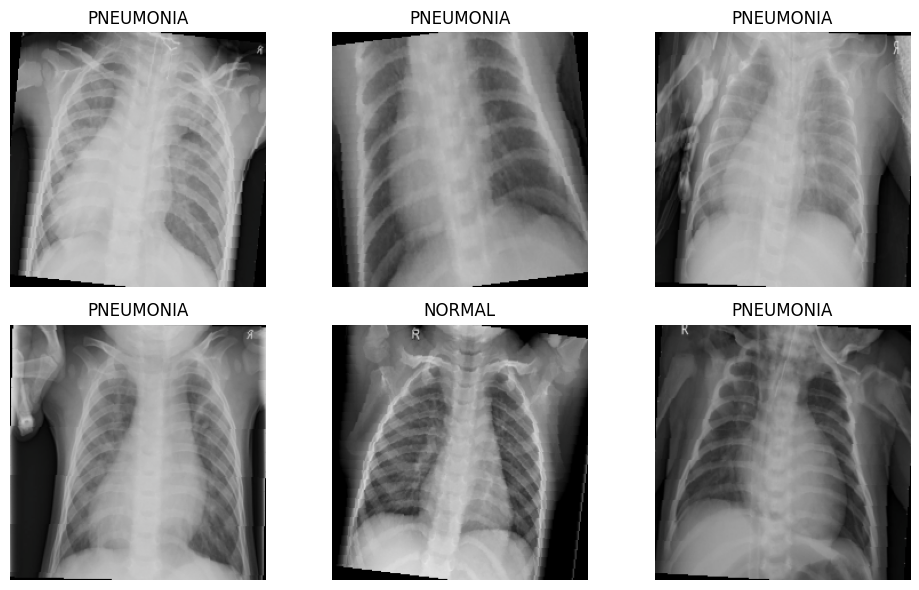

In [27]:
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    imshow(images[i], class_names[labels[i]])
plt.tight_layout()
plt.show()

## 8. Image Size Check

In [28]:
from PIL import Image

sample_path = train_dataset.samples[0][0]
sample_image = Image.open(sample_path)

print("Sample image path:", sample_path)
print("Original image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Sample image path: chest_xray\train\NORMAL\IM-0115-0001.jpeg
Original image size: (2090, 1858)
Image mode: L


## 9. Class Distribution

In [29]:
splits = ["train", "val", "test"]
class_counts = {}

for split in splits:
    split_path = os.path.join(data_dir, split)
    class_counts[split] = {}

    for class_name in class_names:
        class_path = os.path.join(split_path, class_name)
        class_counts[split][class_name] = len(os.listdir(class_path))

class_counts

{'train': {'NORMAL': 1342, 'PNEUMONIA': 3876},
 'val': {'NORMAL': 9, 'PNEUMONIA': 9},
 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}

## 10. Plot Class Distribution

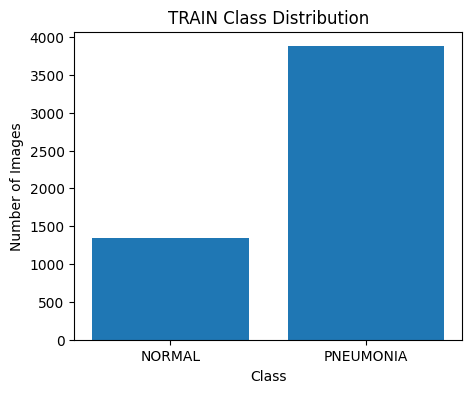

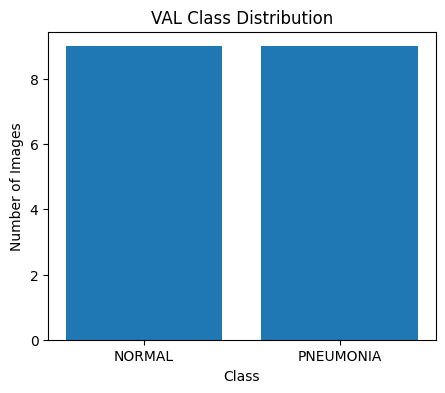

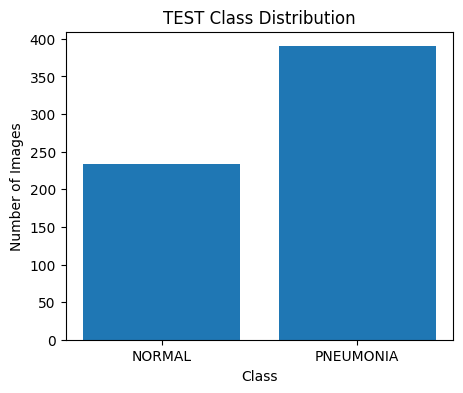

In [30]:
for split in splits:
    plt.figure(figsize=(5, 4))
    plt.bar(class_counts[split].keys(), class_counts[split].values())
    plt.title(f"{split.upper()} Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.show()

## 11. Show One NORMAL and One PNEUMONIA Image

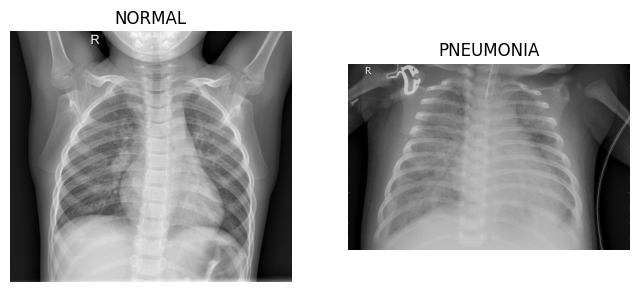

In [31]:
normal_path = train_dataset.samples[train_dataset.targets.index(train_dataset.class_to_idx["NORMAL"])][0]
pneumonia_path = train_dataset.samples[train_dataset.targets.index(train_dataset.class_to_idx["PNEUMONIA"])][0]

normal_img = Image.open(normal_path)
pneumonia_img = Image.open(pneumonia_path)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_img, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

## 12. Training Function

In [32]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_epoch_loss = train_loss / len(train_loader)
        train_epoch_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_acc = val_correct / val_total

        train_losses.append(train_epoch_loss)
        val_losses.append(val_epoch_loss)
        train_accs.append(train_epoch_acc)
        val_accs.append(val_epoch_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.4f}")
        print(f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")
        print("-" * 40)

    return train_losses, val_losses, train_accs, val_accs

## 13. Evaluation Function

In [33]:
def evaluate_model(model, test_loader):
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    print("\nConfusion Matrix:")
    print(cm)

    return acc, report, cm

## 14. Plot Training History

In [34]:
def plot_history(history, title):
    train_losses, val_losses, train_accs, val_accs = history

    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

## 15. Model 1: Baseline CNN

In [35]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 16. Train Baseline CNN

In [36]:
baseline_model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch 1/5
Train Loss: 0.3058 | Train Acc: 0.8955
Val Loss: 0.6843 | Val Acc: 0.6875
----------------------------------------
Epoch 2/5
Train Loss: 0.1398 | Train Acc: 0.9496
Val Loss: 0.7810 | Val Acc: 0.6875
----------------------------------------
Epoch 3/5
Train Loss: 0.1060 | Train Acc: 0.9615
Val Loss: 0.7833 | Val Acc: 0.6250
----------------------------------------
Epoch 4/5
Train Loss: 0.0954 | Train Acc: 0.9649
Val Loss: 1.0075 | Val Acc: 0.6250
----------------------------------------
Epoch 5/5
Train Loss: 0.0952 | Train Acc: 0.9645
Val Loss: 0.7292 | Val Acc: 0.6250
----------------------------------------


## 17. Evaluate Baseline CNN

In [37]:
baseline_acc, baseline_report, baseline_cm = evaluate_model(baseline_model, test_loader)

Accuracy: 0.8157051282051282

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.53      0.68       234
   PNEUMONIA       0.78      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.76      0.78       624
weighted avg       0.84      0.82      0.80       624


Confusion Matrix:
[[125 109]
 [  6 384]]


## 18. Plot Baseline CNN Training Result

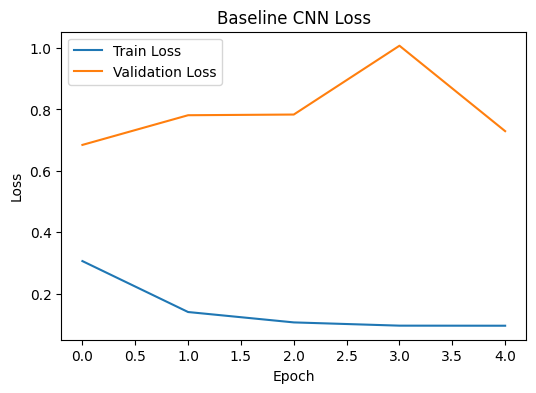

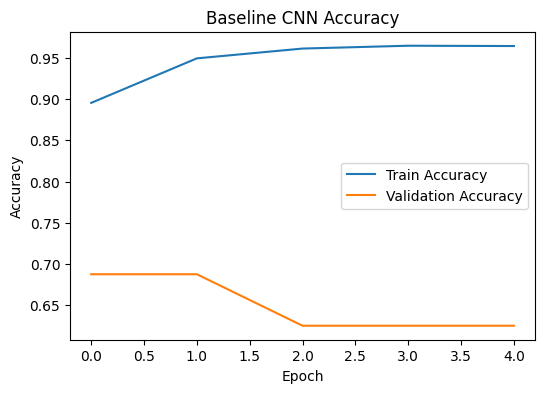

In [38]:
plot_history(baseline_history, "Baseline CNN")

## 19. Store Baseline CNN Result

In [39]:
model_results = {}

model_results["Baseline CNN"] = {
    "Accuracy": baseline_acc,
    "Precision": baseline_report["weighted avg"]["precision"],
    "Recall": baseline_report["weighted avg"]["recall"],
    "F1-score": baseline_report["weighted avg"]["f1-score"]
}

model_results

{'Baseline CNN': {'Accuracy': 0.8157051282051282,
  'Precision': 0.8446398433024169,
  'Recall': 0.8157051282051282,
  'F1-score': 0.8004506740718906}}

## 20. Model 2: Improved CNN

In [40]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 21. Train Improved CNN

In [41]:
improved_model = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.0005
)

improved_history = train_model(
    improved_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch 1/5
Train Loss: 0.3419 | Train Acc: 0.8683
Val Loss: 0.8763 | Val Acc: 0.6250
----------------------------------------
Epoch 2/5
Train Loss: 0.1582 | Train Acc: 0.9411
Val Loss: 0.9921 | Val Acc: 0.6250
----------------------------------------
Epoch 3/5
Train Loss: 0.1351 | Train Acc: 0.9488
Val Loss: 0.9878 | Val Acc: 0.6250
----------------------------------------
Epoch 4/5
Train Loss: 0.1169 | Train Acc: 0.9561
Val Loss: 0.6737 | Val Acc: 0.6250
----------------------------------------
Epoch 5/5
Train Loss: 0.1103 | Train Acc: 0.9571
Val Loss: 0.9497 | Val Acc: 0.5625
----------------------------------------


## 22. Evaluate Improved CNN

In [42]:
improved_acc, improved_report, improved_cm = evaluate_model(improved_model, test_loader)

Accuracy: 0.7644230769230769

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.39      0.55       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.82      0.76      0.73       624


Confusion Matrix:
[[ 91 143]
 [  4 386]]


## 23. Plot Improved CNN Result

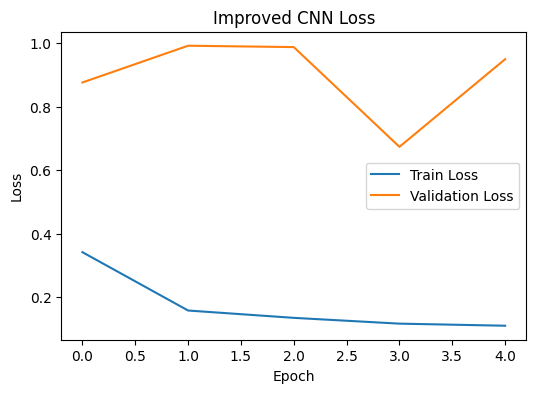

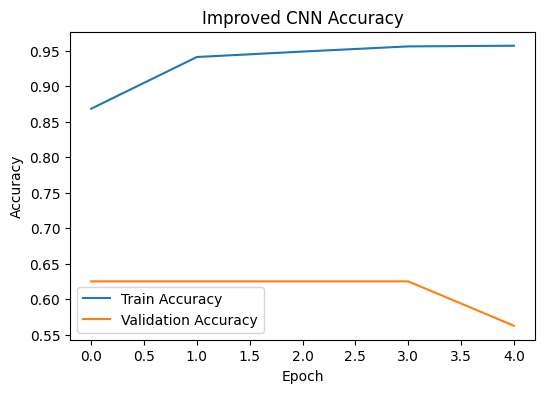

In [43]:
plot_history(improved_history, "Improved CNN")

## 24. Store Improved CNN Result

In [44]:
model_results["Improved CNN"] = {
    "Accuracy": improved_acc,
    "Precision": improved_report["weighted avg"]["precision"],
    "Recall": improved_report["weighted avg"]["recall"],
    "F1-score": improved_report["weighted avg"]["f1-score"]
}

model_results

{'Baseline CNN': {'Accuracy': 0.8157051282051282,
  'Precision': 0.8446398433024169,
  'Recall': 0.8157051282051282,
  'F1-score': 0.8004506740718906},
 'Improved CNN': {'Accuracy': 0.7644230769230769,
  'Precision': 0.8152596756541638,
  'Recall': 0.7644230769230769,
  'F1-score': 0.732474011992684}}

## 25. Model 3: Pretrained CNN (ResNet18)

In [45]:
resnet_model = models.resnet18(pretrained=True)

d:\UsersFolder\Desktop\Pneumonia Predict CV\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\UsersFolder\Desktop\Pneumonia Predict CV\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Personal/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:11<00:00, 3.92MB/s]


## 26. Fine-Tune Final Layer

In [46]:
for param in resnet_model.parameters():
    param.requires_grad = False

num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(num_features, 2)

resnet_model = resnet_model.to(device)

## 27. Train ResNet18

In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

resnet_history = train_model(
    resnet_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch 1/5
Train Loss: 0.3012 | Train Acc: 0.8731
Val Loss: 0.2724 | Val Acc: 0.9375
----------------------------------------
Epoch 2/5
Train Loss: 0.1899 | Train Acc: 0.9250
Val Loss: 0.2390 | Val Acc: 0.8750
----------------------------------------
Epoch 3/5
Train Loss: 0.1580 | Train Acc: 0.9388
Val Loss: 0.3142 | Val Acc: 0.8125
----------------------------------------
Epoch 4/5
Train Loss: 0.1451 | Train Acc: 0.9438
Val Loss: 0.3194 | Val Acc: 0.8125
----------------------------------------
Epoch 5/5
Train Loss: 0.1425 | Train Acc: 0.9440
Val Loss: 0.4001 | Val Acc: 0.6875
----------------------------------------


## 28. Evaluate ResNet18

In [48]:
resnet_acc, resnet_report, resnet_cm = evaluate_model(resnet_model, test_loader)

Accuracy: 0.8782051282051282

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.70      0.81       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624


Confusion Matrix:
[[164  70]
 [  6 384]]


## 29. Plot ResNet18 Result

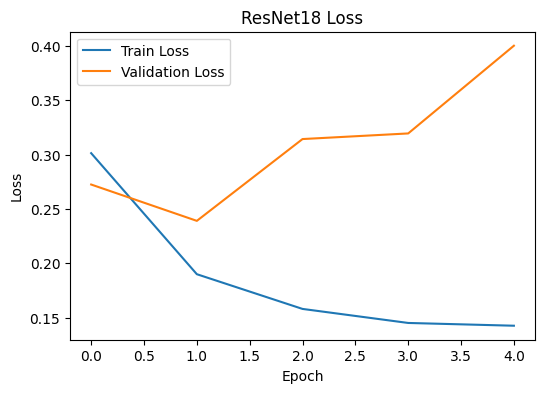

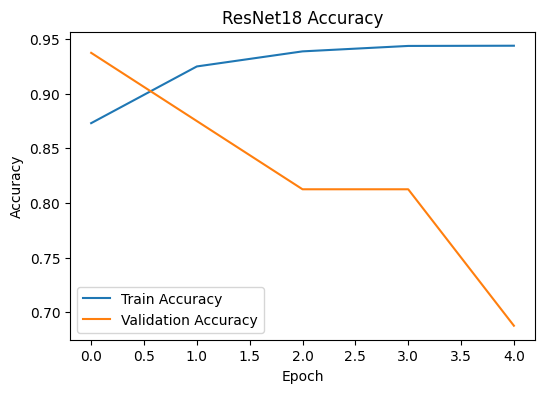

In [49]:
plot_history(resnet_history, "ResNet18")

## 30. Store ResNet18 Result

In [50]:
model_results["ResNet18"] = {
    "Accuracy": resnet_acc,
    "Precision": resnet_report["weighted avg"]["precision"],
    "Recall": resnet_report["weighted avg"]["recall"],
    "F1-score": resnet_report["weighted avg"]["f1-score"]
}

model_results

{'Baseline CNN': {'Accuracy': 0.8157051282051282,
  'Precision': 0.8446398433024169,
  'Recall': 0.8157051282051282,
  'F1-score': 0.8004506740718906},
 'Improved CNN': {'Accuracy': 0.7644230769230769,
  'Precision': 0.8152596756541638,
  'Recall': 0.7644230769230769,
  'F1-score': 0.732474011992684},
 'ResNet18': {'Accuracy': 0.8782051282051282,
  'Precision': 0.8903990671158332,
  'Recall': 0.8782051282051282,
  'F1-score': 0.8731758246914739}}

## 31. Model Comparison

In [51]:
import pandas as pd

results_df = pd.DataFrame(model_results).T
results_df

,Accuracy,Precision,Recall,F1-score
Baseline CNN,0.815705,0.844640,0.815705,0.800451
Improved CNN,0.764423,0.815260,0.764423,0.732474
ResNet18,0.878205,0.890399,0.878205,0.873176


## 32. Plot Model Comparison

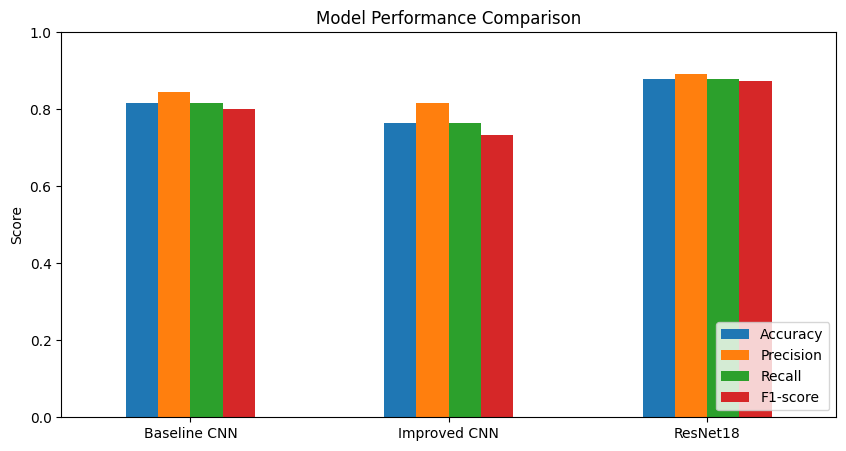

In [52]:
results_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(10, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [53]:
best_model_name = results_df["Accuracy"].idxmax()
best_score = results_df.loc[best_model_name, "Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_score)

Best Model: ResNet18
Best Accuracy: 0.8782051282051282
